<a href="https://colab.research.google.com/github/callumhudson0/CIS-3902-AI-ML-Callum-Hudson/blob/main/Mushroom_Reduced_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Callum Hudson
## Date: 3/12/2026
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [9]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [10]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [11]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [12]:
# One hot encode
X = pd.get_dummies(X)

X.head(), y.value_counts()


(   odor_a  odor_c  odor_f  odor_l  odor_m  odor_n  odor_p  odor_s  odor_y  \
 0   False   False   False   False   False   False    True   False   False   
 1    True   False   False   False   False   False   False   False   False   
 2   False   False   False    True   False   False   False   False   False   
 3   False   False   False   False   False   False    True   False   False   
 4   False   False   False   False   False    True   False   False   False   
 
    spore-print-color_b  ...  gill-color_k  gill-color_n  gill-color_o  \
 0                False  ...          True         False         False   
 1                False  ...          True         False         False   
 2                False  ...         False          True         False   
 3                False  ...         False          True         False   
 4                False  ...          True         False         False   
 
    gill-color_p  gill-color_r  gill-color_u  gill-color_w  gill-color_y  \
 0      

## 5️⃣ Train/test split (Add Code)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


## 6️⃣ Train a small decision tree (Add Code)

In [8]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)




DecisionTreeClassifier(max_depth=3, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [14]:
pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))



Accuracy: 0.959

Confusion Matrix:
 [[1052    0]
 [  83  896]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      1052
           1       1.00      0.92      0.96       979

    accuracy                           0.96      2031
   macro avg       0.96      0.96      0.96      2031
weighted avg       0.96      0.96      0.96      2031



## 8️⃣ Visualize the decision tree (Add Code)

In [18]:
# ALl categorical variables can be teted individually

df.value_counts("odor")
df.value_counts("spore-print-color")
df.value_counts("gill-color")
df.value_counts("gill-size")
df.value_counts("bruises")

,count
gill-size,
b,5612
n,2512


## 9️⃣ Print IF–THEN rules (Add Code)

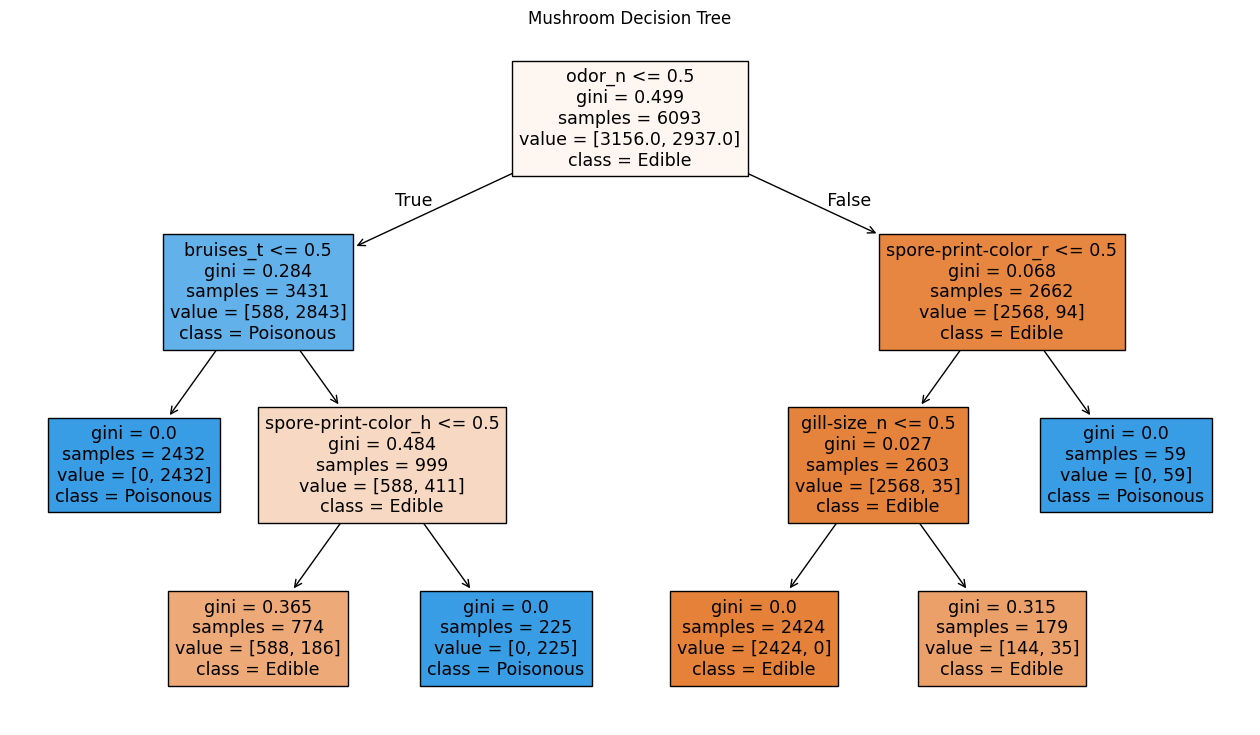

In [22]:
plt.figure(figsize=(16,9))
plot_tree(model, feature_names=X.columns, class_names=["Edible","Poisonous"], filled=True)
plt.title("Mushroom Decision Tree")
plt. show()


In [21]:
print(export_text(model, feature_names=list(X.columns)))

|--- odor_n <= 0.50
|   |--- bruises_t <= 0.50
|   |   |--- class: 1
|   |--- bruises_t >  0.50
|   |   |--- spore-print-color_h <= 0.50
|   |   |   |--- class: 0
|   |   |--- spore-print-color_h >  0.50
|   |   |   |--- class: 1
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- gill-size_n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size_n >  0.50
|   |   |   |--- class: 0
|   |--- spore-print-color_r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?

0.96 (96%)

2. How many poisonous mushrooms were correctly classified?

1052

3. How many poisonous mushrooms were incorrectly predicted as edible?

83

4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?

Misclassifying a poisonous mushroom as edible could lead someone to eat a dangerous mushroom, which could cause serious illness or death. Misclassifying an edible mushroom as poisonous simply means avoiding a safe mushroom, which is much less harmful.

### Understanding the Tree
5. What feature appears at the **root node**?

odor_n

6. What question is the root node asking in plain English?
7. Describe what the **left branch** and **right branch** mean.

“Does the mushroom have odor ‘n’ <= 0.5?” Left means it doesn't (True, n IS <= 0.5), and right means it does (false, n NOT <= 0.5)

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
   L node: bruises_t <= 0.5, R node: spore-print-color_r <= 0.5.
   - What question is each node asking?
   L node: Does the mushroom NOT have bruises? Is the spore print color NOT r? Both are True/False.
   - What does following the left vs right branch mean?
Left: The mushroom doesn't have that feature. Right: The mushrom does have that feature.

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.

odor_n <= 0.5
bruises_t <= 0.5,

-> class = Poisonous

If the mushroom does NOT have odor ‘n’ and does NOT have bruises, the mushroom is predicted to be poisonous.


10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?

Odor, as it appears at the root node, meaning it provides the largest impurity reduction and strongest predictive power.

### Exploration
11. Change `max_depth` to 2. What changed?

The tree becomes smaller and simpler, with fewer splits.
This makes the model easier to interpret, but it may slightly reduce accuracy because fewer patterns can be captured.

12. Change `max_depth` to 5. What changed?

The tree becomes larger and more detailed, with more branches and leaf nodes.
This can improve training accuracy but may also increase the risk of overfitting.
